# 서울 전역 위험수위 재조사 (만관 → 위험수위 재정의)

**동기**: 침수는 하수관이 만관(fill≥1)이 되어야만 나는 게 아니라, **위험 수위(관 80%↑ 충전, 통수능력 저하)**에서도 발생.
만관 기준은 신호를 가렸을 수 있음 → **fill≥0.8(위험수위)**로 서울 전역 강우성 진위감사를 재실행, 만관 기준과 비교.

**임계 근거**: 관악 확인상 fill≥0.7~0.8 위험사건은 100% 강우동반·90%+ 여름. fill≥0.8을 '위험수위'로 채택.

In [1]:
import os; os.chdir("/home/namjun/city_flood")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams['font.family']=['DejaVu Sans']
EB="dataset/processed/eda_based/"; THR=0.8
rel=pd.read_parquet(EB+"sewer_capacity_reliability.parquet")
relset=set(rel.loc[rel.capacity_판정=='신뢰','sensor_id'])
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate','is_stuck_seg'])
sf=sf[sf.sewer_sensor_id.isin(relset)].copy(); sf['danger']=(sf.fill_rate>=THR).astype('int8')
print("신뢰 capacity 센서",sf.sewer_sensor_id.nunique())
# 임계별 도달센서(만관 비교)
comp={thr:sf[sf.fill_rate>=thr].sewer_sensor_id.nunique() for thr in [0.6,0.7,0.8,0.9,1.0]}
print("도달센서:",comp)

신뢰 capacity 센서 455
도달센서: {0.6: 404, 0.7: 384, 0.8: 329, 0.9: 250, 1.0: 194}


## 1. 강우성 진위감사 (fill≥0.8)

In [2]:
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
D=sf[sf.danger==1].copy(); D['year']=D.ts10.dt.year
def pinned(x):
    vc=x.round(3).value_counts(); return vc.iloc[0]/len(x) if len(x) else np.nan
ov=D.groupby('sewer_sensor_id').agg(n_danger=('ts10','size'),frac_2024p=('year',lambda x:(x>=2024).mean()),
    stuck_in_d=('is_stuck_seg','mean'),pinned=('fill_rate',pinned)).reset_index()
X=sf.merge(m,left_on='sewer_sensor_id',right_on='sensor_id',how='left').merge(r[['stn','ts10','rain6h']],left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
X=X[X.rain6h.notna()]
def lf(d):
    b=(d.rain6h>0).mean(); s=d[d.danger==1]
    return pd.Series({'n_cov':int(s.shape[0]),'rain_at_d':((s.rain6h>0).mean() if len(s)>0 else np.nan),'lift':(((s.rain6h>0).mean())/b if (len(s)>0 and b>0) else np.nan)})
A=ov.merge(X.groupby('sewer_sensor_id').apply(lf),on='sewer_sensor_id',how='left')
def cl(r):
    if r.pinned>=0.8: return 'stuck_천장'
    if r.stuck_in_d>=0.6: return 'stuck_구간'
    if (r.n_cov>=30) and (r.lift>=2) and (r.rain_at_d>=0.5): return '진짜_강우성위험'
    if (r.frac_2024p<0.2) or (r.n_cov<30): return '미검증'
    return '비강우_모호'
A['판정']=A.apply(cl,axis=1); A.to_parquet(EB+"sewer_danger_audit.parquet",index=False)
print(A.판정.value_counts().to_string())

판정
미검증         188
stuck_천장    121
비강우_모호       12
진짜_강우성위험      6
stuck_구간      2


## 2. 깔때기 — 병목은 임계가 아니라 AWS 강우 커버리지

In [3]:
funnel=[('fill≥0.8 도달',len(A)),('비-stuck',int((~A.판정.isin(['stuck_천장','stuck_구간'])).sum())),
        ('AWS커버 검증가능(n_cov≥30)',int((A.n_cov>=30).sum())),
        ('강우성 확정(lift≥2)',int((A.판정=='진짜_강우성위험').sum()))]
for k,v in funnel: print(f"  {k:30s} {v}")
genuine=A[A.판정=='진짜_강우성위험'].sort_values('lift',ascending=False)
print("\n진짜 강우성 위험 센서:",genuine.sewer_sensor_id.tolist())
print(genuine[['sewer_sensor_id','n_danger','n_cov','rain_at_d','lift']].round(2).to_string(index=False))

  fill≥0.8 도달                    329
  비-stuck                        206
  AWS커버 검증가능(n_cov≥30)           37
  강우성 확정(lift≥2)                 6

진짜 강우성 위험 센서: ['01-0005', '02-0001', '16-0017', '10-0008', '18-0018', '15-0006']
sewer_sensor_id  n_danger  n_cov  rain_at_d  lift
        01-0005        55   40.0       1.00  2.98
        02-0001      2143  216.0       0.91  2.71
        16-0017       465  401.0       0.76  2.43
        10-0008      1248  540.0       0.67  2.20
        18-0018      1638  185.0       0.99  2.17
        15-0006      1265  112.0       0.62  2.07


## 3. 진짜 위험센서 ↔ 진짜상습 도로 거리 (사슬 가능성)

In [4]:
sn=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','지점명','배수구역','lat','lon'])
rn=pd.read_parquet("dataset/processed/cleaned/road_node.parquet",columns=['sensor_id','lat','lon'])
trust=pd.read_parquet(EB+"road_flood_sensor_trust.parquet")
realroad=rn.merge(trust[trust.판정_final=='진짜상습'][['sensor_id']],on='sensor_id').dropna()
def hav(a,b,c,d):
    R=6371000;p=np.pi/180; x=np.sin((c-a)*p/2)**2+np.cos(a*p)*np.cos(c*p)*np.sin((d-b)*p/2)**2
    return 2*R*np.arcsin(np.sqrt(x))
gs=sn[sn.sensor_id.isin(genuine.sewer_sensor_id)]
for _,s in gs.iterrows():
    d=hav(s.lat,s.lon,realroad.lat.values,realroad.lon.values); i=d.argmin()
    print(f"  {s.sensor_id}({s.지점명},{s.배수구역}) → 최근접 진짜상습도로 {realroad.iloc[i].sensor_id} {d[i]:.0f}m")

  01-0005(세종로 208,청계) → 최근접 진짜상습도로 성산로 494-30 3274m
  02-0001(삼각115,청계) → 최근접 진짜상습도로 성산로 494-30 3774m
  10-0008(방학 706-4,중랑) → 최근접 진짜상습도로 신영동 165 10292m
  15-0006(신월1 103-23,안양천) → 최근접 진짜상습도로 대림동 862-5 7680m
  16-0017(개화육갑문,강서) → 최근접 진짜상습도로 갈현동 466-9 9173m
  18-0018(시흥동 899-14,안양천) → 최근접 진짜상습도로 시흥동 882-61 575m


## 4. 시각화 — 만관 vs 위험수위 비교 + 깔때기

/tmp/ipykernel_330784/1810792579.py:11: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
/tmp/ipykernel_330784/1810792579.py:11: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
/tmp/ipykernel_330784/1810792579.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
/tmp/ipykernel_330784/1810792579.py:11: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
/tmp/ipykernel_330784/1810792579.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
/tmp/ipyke

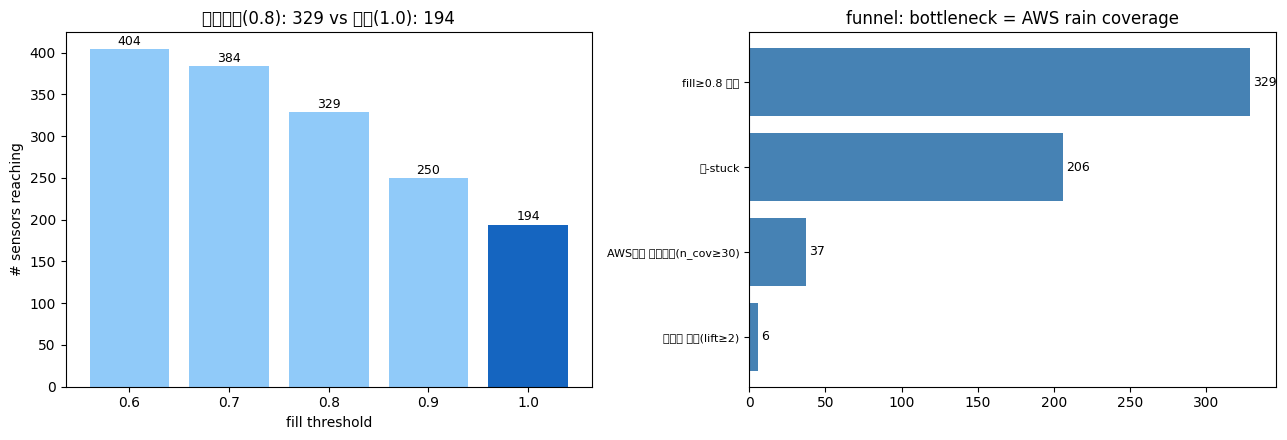

saved


In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
thrs=[0.6,0.7,0.8,0.9,1.0]; reach=[comp[t] for t in thrs]
ax[0].bar([str(t) for t in thrs],reach,color=['#90caf9']*4+['#1565c0'])
for i,v in enumerate(reach): ax[0].text(i,v+5,str(v),ha='center',fontsize=9)
ax[0].set_xlabel('fill threshold'); ax[0].set_ylabel('# sensors reaching'); ax[0].set_title('위험수위(0.8): 329 vs 만관(1.0): 194')
labs=[f[0] for f in funnel]; vals=[f[1] for f in funnel]
ax[1].barh(range(len(labs))[::-1],vals,color='steelblue')
for i,v in enumerate(vals[::-1]): ax[1].text(v+2,i,str(v),va='center',fontsize=9)
ax[1].set_yticks(range(len(labs))[::-1]); ax[1].set_yticklabels([f[0] for f in funnel],fontsize=8)
ax[1].set_title('funnel: bottleneck = AWS rain coverage')
plt.tight_layout(); os.makedirs('reports/figures_sewer',exist_ok=True)
plt.savefig('reports/figures_sewer/08_danger_audit.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론
- **위험수위(fill≥0.8)로 도달 센서 194→329(1.7배)**: 만관은 안 가도 위험수위까진 차는 센서가 많음 = 만관 기준이 신호를 가렸음(사용자 지적 옳음).
- **그러나 강우 검증된 진짜 위험센서는 6개**(만관 5와 비슷). 병목은 임계가 아니라 **①AWS 강우 커버(2024-06~)라 센서당 검증가능 위험사건이 30+ 인 곳이 37개뿐 ②stuck 오염 123센서**.
- 진짜 6: 01-0005·02-0001·10-0008·15-0006(신규)·16-0017·18-0018. → 만관 set보다 신규 4개 추가.
- **다음**: AWS 강우 잔여분/레이더로 커버 확대하면 미검증 188 중 상당수 검증 가능 → 위험수위 학습셋 대폭 확대 여지.